## SHEATH model predictions to perform inference using DAGGER code

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt 
import h5py
from astropy.time import Time
import numpy as np
import glob
import pandas as pd
import re
from datetime import datetime

import dask.dataframe as dd

from datetime import datetime
import torch
import torch.nn as nn
import tqdm
from scipy.special import sph_harm
from sklearn.preprocessing import StandardScaler
from torch.utils import data
import pickle
import os


In [3]:
import sys
sys.path.append('/home/jupyter/Vishal/clean_fdlx/2023-FDL-X-Geo/2020-FDL-X-Geo/')
# from dataloader import SuperMAGIAGADataset,OMNIDataset,ShpericalHarmonicsDatasetBucketized
# from utils.data_utils import get_omni_data,get_iaga_data_as_list
# from utils.splitter import generate_indices
# from metricgen import EventMetrics,Generate_metrics
# from Forecaster import Forecaster,Generate_complete_weimer_forecast,Generate_weimer_forecast
from models.geoeffectivenet import *
import pickle
from utils.helpers import dipole_tilt


In [4]:
import matplotlib.colors

class SqueezedNorm(matplotlib.colors.Normalize):
    def __init__(self, vmin=None, vmax=None, mid=0, s1=2, s2=2, clip=False):
        self.vmin = vmin # minimum value
        self.mid  = mid  # middle value
        self.vmax = vmax # maximum value
        self.s1=s1; self.s2=s2
        f = lambda x, zero,vmax,s: np.abs((x-zero)/(vmax-zero))**(1./s)*0.5
        self.g = lambda x, zero,vmin,vmax, s1,s2: f(x,zero,vmax,s1)*(x>=zero) - \
                                             f(x,zero,vmin,s2)*(x<zero)+0.5
        matplotlib.colors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        r = self.g(value, self.mid,self.vmin,self.vmax, self.s1,self.s2)
        return np.ma.masked_array(r)

In [5]:
FLAGS = {}
FLAGS["dataset_dir"]='.'
FLAGS["id"]=''
FLAGS["model"]='NeuralRNNWiemer'
FLAGS["past_omni_length"]=120
FLAGS["past_supermag_length"]=10
FLAGS["future_length"]=1
FLAGS["lag"]=1
FLAGS["skip"]=1
FLAGS["nmax"]=20
FLAGS["batch_size"]=4096
FLAGS["num_epochs"]=10000
FLAGS["save_model_frequency"]=20
FLAGS["learning_rate"]=5e-5
FLAGS["l2reg"] = 1.6e-5
FLAGS["weight_decay"]=0.0
FLAGS['tiny']=False
FLAGS['zero_omni']=False
FLAGS['zero_supermag']=False
FLAGS['plot']=False
FLAGS['validation']=False
FLAGS['targets']='a_nm_dbn_nez'
FLAGS['loss']='MaxSqEr'
FLAGS['scaler']=None
FLAGS["omni_resolution"] = 1
FLAGS['dropout_prob'] = 0.1
FLAGS['n_hidden'] = 8
FLAGS['spherical_path']='../data/spherical_all_stations/spherical_harm_40_maglat_no_intercept/'
FLAGS['year'] = '2017'
FLAGS['iaga_dataset']=f"../data_local/iaga/{FLAGS['year']}/{FLAGS['year']}/"
FLAGS['mhd_dataset']=None
FLAGS["basepath"] = "/home/jupyter/Vishal/clean_fdlx/2023-FDL-X-Geo/2020-FDL-X-Geo/Best/Reg_Faster_FULL_NeuralRNNWiemer_MAE_120_20_8_5000.0_50.0/Best/"

FLAGS['f107_dataset']='/home/jupyter/Vishal/omni/f107.npz'
FLAGS['omni_dataset']='/home/jupyter/Vishal/clean_fdlx/2023-FDL-X-Geo/2020-FDL-X-Geo/sheath/logs/sheath_sw_data_test_for_dagger.h5'
FLAGS['gridded_loss']=False
FLAGS["ckpts"]=glob.glob(f"{FLAGS['basepath']}*.ckpt")[0]

In [6]:
future_length = 1 #WAS DEFAULT IN THE CODE
past_omni_length = FLAGS["past_omni_length"]
nmax = FLAGS['nmax']
targets = ["dbe_nez", "dbn_nez"]
lag = FLAGS['lag']
learning_rate = FLAGS["learning_rate"]
batch_size = 2048
omni_resolution = FLAGS["omni_resolution"]
dropout_prob = FLAGS['dropout_prob']
l2reg = FLAGS['l2reg']
n_hidden = FLAGS['n_hidden']

# load scaler to unstandardize data
scalers = pickle.load(open(f"{FLAGS['basepath']}scalers.p", "rb"))
_mean, _std = scalers["supermag"]

dbe_mean, dbn_mean = _mean
dbe_std, dbn_std = _std

In [7]:
omni_data = pd.read_hdf(FLAGS['omni_dataset'])
omni_data

,bx,by,bz,vx,vy,vz,density,psw,temperature,xgse,ygse,zgse,clock_angle
Date,,,,,,,,,,,,,
2017-09-25 10:39:30.090000+00:00,1.271765,2.142053,0.515188,507.778748,0.0,0.0,2.465894e-20,6.358043e-09,282821.187500,0.0,0.0,0.0,1.334768
2017-09-25 11:03:43.340000+00:00,1.224619,2.044251,0.623681,504.680939,0.0,0.0,2.457741e-20,6.259937e-09,269509.562500,0.0,0.0,0.0,1.274676
2017-09-25 11:20:42.121250+00:00,1.218480,1.932215,0.547689,513.494141,0.0,0.0,2.297326e-20,6.057502e-09,283255.281250,0.0,0.0,0.0,1.294590
2017-09-25 11:23:55.527500+00:00,1.427943,2.130201,0.342804,512.523193,0.0,0.0,2.353128e-20,6.181197e-09,292205.312500,0.0,0.0,0.0,1.411239
2017-09-25 11:24:56.996250+00:00,1.509717,1.856037,0.256201,515.585876,0.0,0.0,2.402303e-20,6.386013e-09,296803.718750,0.0,0.0,0.0,1.433627
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-09-28 12:21:40.590000+00:00,-0.030059,2.779880,0.424399,427.966461,0.0,0.0,2.921566e-20,5.351002e-09,213514.187500,0.0,0.0,0.0,1.419298
2017-09-28 12:22:35.402500+00:00,-2.715396,2.990658,0.193019,492.660065,0.0,0.0,2.170158e-20,5.267276e-09,272615.656250,0.0,0.0,0.0,1.506345
2017-09-28 13:46:03.902500+00:00,0.160137,2.709611,0.836490,425.751648,0.0,0.0,3.054725e-20,5.537130e-09,210924.203125,0.0,0.0,0.0,1.271366


In [8]:
new_omni = omni_data.resample('60S').mean()
new_omni

,bx,by,bz,vx,vy,vz,density,psw,temperature,xgse,ygse,zgse,clock_angle
Date,,,,,,,,,,,,,
2017-09-25 10:39:00+00:00,1.271765,2.142053,0.515188,507.778748,0.0,0.0,2.465894e-20,6.358043e-09,282821.187500,0.0,0.0,0.0,1.334768
2017-09-25 10:40:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-25 10:41:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-25 10:42:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-25 10:43:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-09-28 16:44:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-28 16:45:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-28 16:46:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
new_omni = new_omni.interpolate()

In [10]:
class Sheath_Dagger_Dataloader(data.Dataset):
    def __init__(
        self,
        omni_data,
        f107_dataset,
        past_omni_length=120,
        future_length=10,
        lag=0,
        scaler=None,
        training_batch=True,
        nmax=20,
        inference=False
    ):
        
        self.omni = omni_data.values
        self.dates = omni_data.index.values
        #This shape is (n_total,n_omni)

        print("extracting f107")
        self.f107path = f107_dataset
        f107_data = np.load(f107_dataset)
        
        omni_columns = np.array(omni_data.columns.tolist() + ["dipole", "f107"])

        self.omni_features = omni_columns
        # import pdb; pdb.set_trace()
        match =  np.argmin(np.abs(pd.to_datetime(self.dates,unit='s').to_numpy()[...,None]\
                                  -pd.to_datetime(f107_data["dates"],unit='s').to_numpy()[None,...]),axis=-1)
        
        f107_tmp = f107_data["f107"][match]
        self.omni = np.concatenate([self.omni,dipole_tilt(self.dates).reshape([-1,1]),f107_tmp.reshape([-1,1])],axis=-1)
    
        omni_mean, omni_std = scaler["omni"]
        self.omni = (self.omni-omni_mean)/omni_std
        
        self.window_length = past_omni_length+lag-1
        self.past_omni_length = past_omni_length
        self.future_length = future_length
        self.lag = lag

        self._nbasis = nmax
        
        self.sg_indices_dict = {}
        # There was this whole bucketizing business. Basically, we need to take in data from idx:idx+self.past_omni_length.
        # Everything else is not useful!
        
    def __len__(self):
        return (
            len(self.omni)
            - self.past_omni_length
            - self.future_length
            - self.lag
            + 1
        )

    def __getitem__(self, index):
        index = index + self.past_omni_length

        return (
            self.omni[index - self.past_omni_length : index][None,...],
            None,
            None,
            None,
            self.dates[index - self.past_omni_length : index],
            self.dates[index + self.lag : index + self.future_length + self.lag]
        )
    

In [11]:
scalers['omni'][0].shape

(15,)

<AxesSubplot:xlabel='Date'>

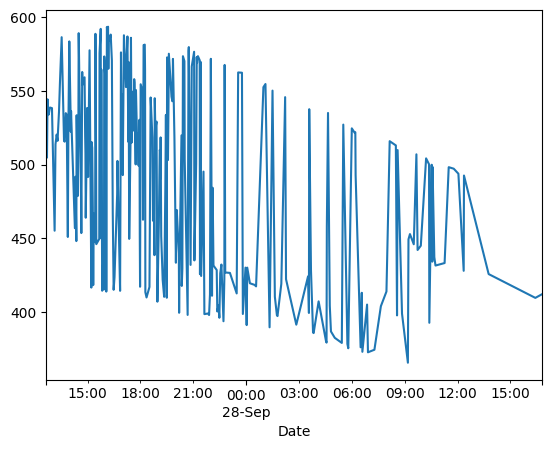

In [12]:
new_omni.iloc[3000:]['vx'].plot()

In [13]:
val_dataset = Sheath_Dagger_Dataloader(
        new_omni.iloc[3000:],
        scaler=scalers,
        future_length = future_length,
        past_omni_length=past_omni_length,
        training_batch=False,
        f107_dataset=FLAGS['f107_dataset'],
    )

extracting f107


In [14]:
len(val_dataset.omni)

1690

In [15]:
FLAGS["ckpts"]

'/home/jupyter/Vishal/clean_fdlx/2023-FDL-X-Geo/2020-FDL-X-Geo/Best/Reg_Faster_FULL_NeuralRNNWiemer_MAE_120_20_8_5000.0_50.0/Best/epoch=8-step=3077.ckpt'

In [16]:
model = NeuralRNNWiemer.load_from_checkpoint(f'{FLAGS["ckpts"]}', strict=False, 
                                                 past_omni_length=past_omni_length,
                                                 future_length=future_length,
                                                 supermag_features = None,
                                                 omni_features=val_dataset.omni_features,
                                                 nmax=nmax,omni_resolution=omni_resolution,
                                                 targets_idx=targets,learning_rate = learning_rate,
                                                 l2reg=l2reg,
                                                 dropout_prob=dropout_prob,
                                                 n_hidden=n_hidden,
                                                 loss=FLAGS['loss'])

/opt/conda/lib/python3.7/site-packages/pytorch_lightning/utilities/migration/migration.py:200: PossibleUserWarning: You have multiple `ModelCheckpoint` callback states in this checkpoint, but we found state keys that would end up colliding with each other after an upgrade, which means we can't differentiate which of your checkpoint callbacks needs which states. At least one of your `ModelCheckpoint` callbacks will not be able to reload the state.
  category=PossibleUserWarning,
Lightning automatically upgraded your loaded checkpoint from v1.4.6 to v1.9.5. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint --file ../../Best/Reg_Faster_FULL_NeuralRNNWiemer_MAE_120_20_8_5000.0_50.0/Best/epoch=8-step=3077.ckpt`


Constructing spherical harmonics functions


In [17]:
if torch.cuda.is_available():
    model = model.cuda().double()
else:
    model = model.double()


In [18]:
_mlt = np.linspace(0,2*np.pi,180)
_colat = np.linspace(0,np.pi/2,180)
_mlt,_colat = np.meshgrid(_mlt,_colat)

In [19]:
def _float(tensor):
    return torch.from_numpy(tensor.astype(np.float64)).double()

In [20]:
from tqdm import tqdm

In [21]:
Predictions = {'dbe':[],'dbn':[]}
dates = {'dbe':[],'dbn':[]}
Coefficients = {'dbe':[],'dbn':[]}
mean = {'dbe': dbe_mean, 'dbn':dbn_mean}
std = {'dbe': dbe_std, 'dbn':dbn_std}
m = {'dbe': 0, 'dbn': 1}
for past_omni, _, _, _, past_dates, future_dates in tqdm(val_dataset):
    _, _coeffsdb, db_pred = model(_float(past_omni), _float(np.array([0])),_float( _mlt),_float( _colat), _float(past_dates), _float(future_dates))
    for k in ['dbe','dbn']:
        Coefficients[k].append(_coeffsdb[..., m[k]].detach().numpy())
        Predictions[k].append(db_pred[..., m[k]].detach().numpy()*std[k]+mean[k])
        dates[k].append(future_dates)

1690it [5:22:16, 11.44s/it]                            


RuntimeError: Expected 3D or 4D (batch mode) tensor with optional 0 dim batch size for input, but got:[1, 15, 1, 0]

In [22]:
np.savez("../logs/dagger_forecast.npz",Predictions=Predictions,Coefficients=Coefficients,dates=dates)

In [114]:
plt.style.use("dark_background")

In [115]:
import matplotlib.cm as cm

In [116]:
class SqueezedNorm(matplotlib.colors.Normalize):
    def __init__(self, vmin=None, vmax=None, mid=0, s1=2, s2=2, clip=False):
        self.vmin = vmin # minimum value
        self.mid  = mid  # middle value
        self.vmax = vmax # maximum value
        self.s1=s1; self.s2=s2
        f = lambda x, zero,vmax,s: np.abs((x-zero)/(vmax-zero))**(1./s)*0.5
        self.g = lambda x, zero,vmin,vmax, s1,s2: f(x,zero,vmax,s1)*(x>=zero) - \
                                             f(x,zero,vmin,s2)*(x<zero)+0.5
        matplotlib.colors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        r = self.g(value, self.mid,self.vmin,self.vmax, self.s1,self.s2)
        return np.ma.masked_array(r)


In [119]:
save_path = "../DAGGER_movie/"
if not os.path.isdir(save_path):
    os.makedirs(save_path)

In [120]:
for time_ind in range(len(val_dataset.omni)):
    k = 'dbn'
    f = 1
    fig1 = plt.figure(figsize=(12*f,8*f),dpi=100)
    gs = fig1.add_gridspec(8, 2)

    theta = _mlt 
    phi = _colat 
    cmap=cm.get_cmap("RdYlBu_r",17)
    ax1 = fig1.add_subplot(gs[:-1,0], projection='polar')
    ax1.set_theta_offset(-np.pi/2)
    ax2 = fig1.add_subplot(gs[:-1,1], projection='polar')
    ax2.set_theta_offset(-np.pi/2)
    # ax3 = fig1.add_subplot(gs[:-1,2], projection='polar')
    # ax3.set_theta_offset(-np.pi/2)
    cax = fig1.add_subplot(gs[-1,:])

    cax.cla()

    dbH2 = Predictions[k][time_ind] #np.sqrt(np.square(Targets['dbe'][:,:,start:end+1])+np.square(Targets['dbn'][:,:,start:end+1]))

    maxval = np.nanpercentile(dbH2,95)
    minval = np.nanpercentile(dbH2,5)
    print(minval,maxval)

    # norm=SqueezedNorm(vmin=minval, vmax=maxval, mid=np.nanmean(dbH2), s1=2, s2=2)

    dbH = Predictions[k][time_ind] #np.sqrt(np.square(fdl_on_weimergrid_gif['dbe'][:,:,start:end+1][...,time_ind])+np.square(fdl_on_weimergrid_gif['dbn'][:,:,start:end+1][...,time_ind]))
    c2=ax2.pcolormesh(theta,phi, dbH,cmap=cmap) #,norm=norm)  
    # ax2.set_ylim([np.nanmin(Mcolat_sup_all[k][time_ind]),np.nanmax(Mcolat_sup_all[k][time_ind])])
    ax2.grid(linewidth=1,color='white',linestyle='--')
    # ax2.text(3.5,1.1,f"DAGGER 30-min forecast",fontsize=15*f)

    #==========================
    k = 'dbe'

    dbH2 = Predictions[k][time_ind] #np.sqrt(np.square(Targets['dbe'][:,:,start:end+1])+np.square(Targets['dbn'][:,:,start:end+1]))

    maxval = np.nanpercentile(dbH2,95)
    minval = np.nanpercentile(dbH2,5)
    # norm=SqueezedNorm(vmin=minval, vmax=maxval, mid=np.nanmean(dbH2), s1=2, s2=2)

    dbH = Predictions[k][time_ind] #np.sqrt(np.square(fdl_on_weimergrid_gif['dbe'][:,:,start:end+1][...,time_ind])+np.square(fdl_on_weimergrid_gif['dbn'][:,:,start:end+1][...,time_ind]))
    c2=ax1.pcolormesh(theta,phi, dbH,cmap=cmap)#,norm=norm)  
    # ax1.set_ylim([np.nanmin(Mcolat_sup_all[k][time_ind]),np.nanmax(Mcolat_sup_all[k][time_ind])])
    ax1.grid(linewidth=1,color='white',linestyle='--')
    # ax1.text(3.5,1.1,f"FDL 30-min forecast",fontsize=15*f)
    fig1.colorbar(c2, cax=cax,orientation='horizontal')
    cax.set_xlabel(r'Northward and Eastward magnetic field perturbation ($\delta\mathrm{B}_{\mathrm{N}}$) (nT)',fontsize=15)
    plt.savefig(f"{save_path}Dagger_{time_ind:04d}.png",dpi=200)
    plt.close()

-50.20342448685275 155.42151018910693


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:29: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:44: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.


-99.35957218416867 73.07711649940687
-124.85713152607386 168.83218598350547
-95.99171798116916 134.04426405007789
-156.229671991251 166.97756662174132
-46.865817272112004 82.76999421659819
-73.50714109229341 44.851031420922475
-76.26222895519811 104.1463341025418
-39.86031852633581 90.69915826112684
-64.74286016889704 120.46473673392002
-28.984410219792643 30.814564552057583
-74.49082529929498 71.66112950219105
-124.82146961174729 122.7566345208353
-47.74226954740079 112.96133109351742
-78.77094035911581 76.95057572068461
-86.78323058726583 111.66597702236484
-172.07202635532158 166.8136726543036
-89.69311855676521 19.185310894981257
-134.23127348603217 115.2748497100538
-131.21361281124862 74.18733582171072
-20.668809467223276 45.236908611649426
-87.0828399375232 137.06500068653193
-49.00943414654831 83.79168674312984
-117.70761381723555 40.49760544368811
-144.08320725332734 113.05622398757119
-152.66312838023546 144.04352570481953
-92.84511417211345 71.35181600027299
-82.578310823988